# 09-Multi-Agent Network Topologies

In the previous lessons, we built a highly capable, autonomous agent. By giving a single LLM access to external tools and a cyclic `StateGraph`, we achieved recursive problem-solving.

However, as Enterprise systems scale, a fatal architectural flaw emerges: **The Monolithic Context Collapse**.
If you attempt to build an "Enterprise AI" by giving a single agent 50 different tools (Database Querying, Emailing, Code Execution, HR Access) and a massive 5,000-word system prompt detailing every corporate policy, the LLM's probability space shatters. The attention mechanism dilutes, and the agent begins to confuse its tools, using the Python execution tool when it should have queried the HR database.

To solve this, we must mathematically partition the policy network. Instead of one massive agent, we construct a **Multi-Agent Network Topology**. We deploy multiple specialized agents, each with a narrow system prompt and a strictly limited subset of tools.

In this lesson, we will engineer the **Peer-to-Peer (P2P) Handoff Topology**, where distinct agents autonomously transfer control to one another over a shared global state.

Let's set up our environment.

In [3]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph matplotlib seaborn
from typing import TypedDict, Annotated, Literal
import operator
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Multi-Agent Topologies Environment Ready.")

✅ Systems Architecture & Multi-Agent Topologies Environment Ready.


# 1. The Mathematics of Policy Partitioning

In a single-agent system, the policy network $\pi_\theta$ must select an action $a_t$ from the complete global action space $\mathcal{A}_{global}$:


$$a_t \sim \pi_\theta(a_t | S_{global}, \mathcal{A}_{global})$$

As $|\mathcal{A}_{global}|$ grows, the probability of selecting the correct tool drops significantly due to attention dilution.

In a **Multi-Agent Topology**, we partition the action space into distinct, non-overlapping subspaces $\mathcal{A}_1, \mathcal{A}_2$. We then instantiate two separate policy nodes (Agents), each constrained to its specific domain.
To allow collaboration, we inject a strictly typed **Handoff Tool** into each agent's action space.

$$\mathcal{A}_{Support} = \{\text{fetch\_data}, \text{transfer\_to\_security}\}$$

$$\mathcal{A}_{Security} = \{\text{unlock\_account}, \text{transfer\_to\_support}\}$$

By making the transfer an explicit, physical tool call, the agents map their conversational logic directly into the LangGraph routing engine.

# 2. Architecting the Peer-to-Peer Network

Let's build a physical, executable Multi-Agent network.
We will simulate an IT Department with two distinct nodes:

1. **The Support Agent**: Has access to read user data. It *cannot* modify the database.
2. **The Security Agent**: Has elevated physical privileges to unlock accounts. It is isolated from the user.

If the Support Agent encounters a locked account, it must physically transfer control to the Security Agent, who will execute the unlock tool and transfer control back.

In [4]:
# --- 🕸️ The Peer-to-Peer Multi-Agent Engine ---

# 1. Define the Global Shared State (The Scratchpad)
class GlobalState(TypedDict):
    # All agents append to this single, unified conversational bus
    messages: Annotated[list, add_messages]
    # Tracks which agent is currently authorized to act
    active_agent: str

# 2. Define Domain-Isolated Physical Tools
@tool
def fetch_user_record(user_id: str) -> str:
    """Tier 1 Support Tool: Fetches read-only user records."""
    print(f"   🔍 [TOOL: Database] Fetching record for {user_id}...")
    return f"User {user_id} | Balance: $500 | Status: LOCKED due to suspicious login."

@tool
def unlock_user_account(user_id: str) -> str:
    """Tier 2 Security Tool: Physically unlocks an account. ELEVATED PRIVILEGES REQUIRED."""
    print(f"   🔓 [TOOL: Security] Executing physical unlock for {user_id}...")
    return f"SUCCESS: Account {user_id} has been securely unlocked."

# 3. Define the Handoff Tools (The Mathematical Edges)
@tool
def transfer_to_security() -> str:
    """Call this tool to transfer the active session to the Security Agent."""
    print("   🔀 [HANDOFF] Support Agent is transferring control to Security...")
    return "TRANSFER_SECURITY"

@tool
def transfer_to_support() -> str:
    """Call this tool to transfer the active session back to the Support Agent."""
    print("   🔀 [HANDOFF] Security Agent is returning control to Support...")
    return "TRANSFER_SUPPORT"

# 4. Initialize Policy Networks
llm = ChatOllama(model="llama3.2", temperature=0)

# Bind isolated tools to specific agents
support_llm = llm.bind_tools([fetch_user_record, transfer_to_security])
security_llm = llm.bind_tools([unlock_user_account, transfer_to_support])

# 5. Define the Agent Nodes
def support_node(state: GlobalState):
    print("   🎧 [NODE: Support Agent] Processing state...")
    prompt = [SystemMessage(content="You are Tier 1 Support. You can fetch user records. If a record is LOCKED, you cannot unlock it. You MUST call the `transfer_to_security` tool. Be polite.")]
    response = support_llm.invoke(prompt + state["messages"])
    return {"messages": [response], "active_agent": "Support"}

def security_node(state: GlobalState):
    print("   🛡️ [NODE: Security Agent] Processing state...")
    prompt = [SystemMessage(content="You are Tier 2 Security. You have elevated access to unlock accounts. Once you unlock an account, you MUST call the `transfer_to_support` tool immediately.")]
    response = security_llm.invoke(prompt + state["messages"])
    return {"messages": [response], "active_agent": "Security"}

# 6. Define the Unified Tool Executor and Dynamic Router
def tool_executor_node(state: GlobalState):
    """Physically executes tools for ANY agent and returns the Observation."""
    last_msg = state["messages"][-1]
    tool_responses = []
    
    for tc in last_msg.tool_calls:
        if tc["name"] == "fetch_user_record":
            res = fetch_user_record.invoke(tc["args"])
        elif tc["name"] == "unlock_user_account":
            res = unlock_user_account.invoke(tc["args"])
        elif tc["name"] == "transfer_to_security":
            res = transfer_to_security.invoke(tc["args"])
        elif tc["name"] == "transfer_to_support":
            res = transfer_to_support.invoke(tc["args"])
            
        tool_responses.append(ToolMessage(content=res, tool_call_id=tc["id"]))
        
    return {"messages": tool_responses}

def dynamic_router(state: GlobalState):
    """Reads the State to route the mathematical flow."""
    last_msg = state["messages"][-1]
    
    # 1. Check if the last message was a Tool result. 
    # If yes, we MUST route back to an agent to read the result.
    if last_msg.type == "tool":
        if "TRANSFER_SECURITY" in last_msg.content:
            return "Security"
        if "TRANSFER_SUPPORT" in last_msg.content:
            return "Support"
        # If no handoff was triggered, route back to the agent who called the tool
        return state["active_agent"]
        
    # 2. Check if the last message was from an AI.
    if last_msg.type == "ai":
        # If the AI wants to use a tool, route to Executor
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            return "Tools"
        # If the AI responded with pure text and no tools, the task is complete
        else:
            return END
            
    return END

# 7. Compile the Multi-Agent Graph
print("--- 🏗️ Compiling P2P Multi-Agent StateGraph ---")
workflow = StateGraph(GlobalState)

workflow.add_node("Support", support_node)
workflow.add_node("Security", security_node)
workflow.add_node("Tools", tool_executor_node)

# Execution always begins at Tier 1 Support
workflow.add_edge(START, "Support")

# In modern LangGraph, you can pass the router function directly without 
# hardcoding the target arrays. It will dynamically follow the returned string.
workflow.add_conditional_edges("Support", dynamic_router)
workflow.add_conditional_edges("Security", dynamic_router)
workflow.add_conditional_edges("Tools", dynamic_router)

app = workflow.compile()

# 8. Execute the Physical Graph
print("\n--- 🚀 Initiating Enterprise Multi-Agent Run ---")
S_0 = {
    "messages": [HumanMessage(content="My username is Aris99. I can't log in. Can you fix it?")],
    "active_agent": "Support"
}

# We set a generous recursion limit because multi-agent handoffs require many cyclic hops
config = {"recursion_limit": 15}

final_state = app.invoke(S_0, config=config)

print("\n--- 🏁 Final Conversational Output ---")
for msg in final_state["messages"]:
    if msg.type in ["human", "ai"] and msg.content:
        role = "👤 User" if msg.type == "human" else "🤖 Agent"
        print(f"{role}: {msg.content}")

print("\n--- 💡 Engineering Insight ---")
print("We just executed a true Multi-Agent P2P Handshake. The Support Agent (Llama 3.2) mathematically recognized that 'unlocking' was strictly outside its probability space. It physically invoked the `transfer_to_security` tool. The Python router intercepted this signal, dynamically shifted the State payload to the Security Node, which executed the elevated permission tool, and then passed control back to Support to say goodbye. Complete domain isolation achieved.")

--- 🏗️ Compiling P2P Multi-Agent StateGraph ---

--- 🚀 Initiating Enterprise Multi-Agent Run ---
   🎧 [NODE: Support Agent] Processing state...
   🔀 [HANDOFF] Support Agent is transferring control to Security...
   🛡️ [NODE: Security Agent] Processing state...

--- 🏁 Final Conversational Output ---
👤 User: My username is Aris99. I can't log in. Can you fix it?
🤖 Agent: Hello Aris99,

I'm happy to help you with your login issue! However, I need to follow our security protocols to ensure the account's security.

To assist you further, I've initiated a transfer to our Security team. They will be able to investigate and resolve the issue with your account.

Please wait for a moment while they work on it. Once they've completed the process, you'll receive an email with instructions on how to access your account again.

If you have any urgent matters that require attention before then, please let me know and I'll do my best to assist you further.

Thank you for your patience and cooperation.

# 3. Visualizing the Multi-Agent Topology

To scientifically map the structural difference between a single autonomous agent and a Multi-Agent Network, let's visualize the exact StateGraph we just executed.

/tmp/ipykernel_67144/1239942111.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  bus = patches.Rectangle((2, 0.5), 10, 1.5, fill=True, color='#f1c40f', alpha=0.2, linewidth=2, edgecolor='#f39c12')


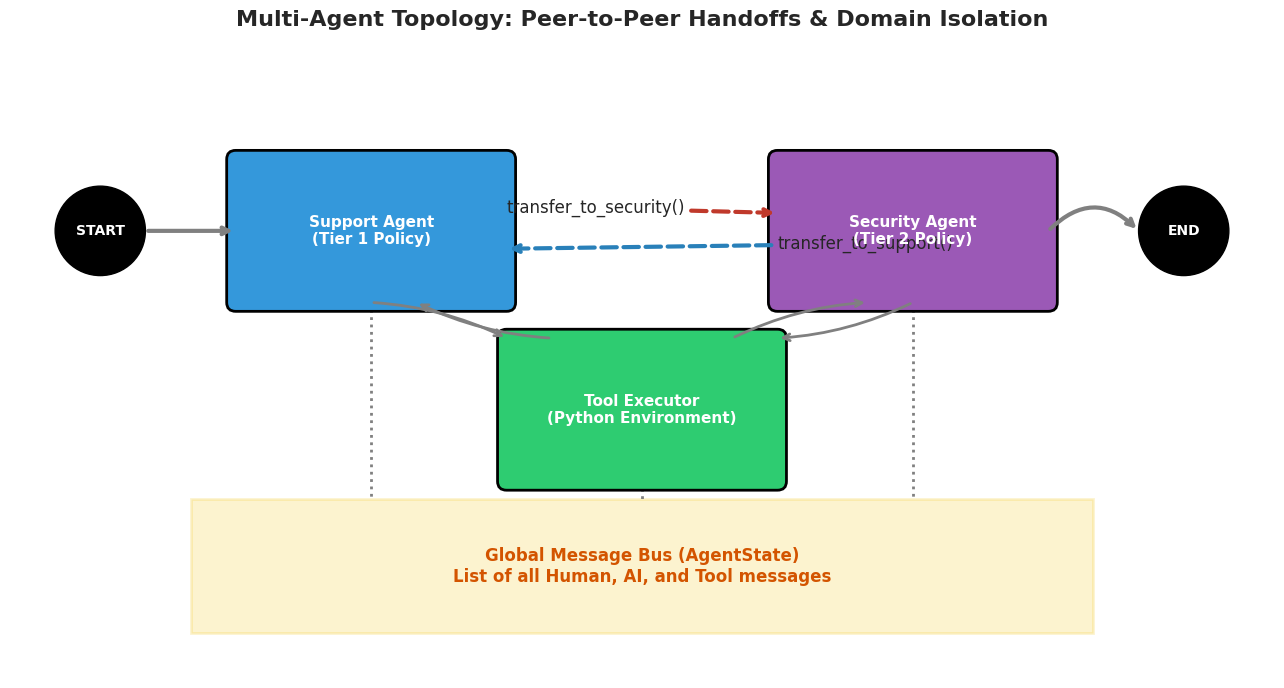

In [5]:
# Visualizing the P2P Multi-Agent Graph Topology
fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle("Multi-Agent Topology: Peer-to-Peer Handoffs & Domain Isolation", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Draw the Global State Bus (The Shared Scratchpad)
bus = patches.Rectangle((2, 0.5), 10, 1.5, fill=True, color='#f1c40f', alpha=0.2, linewidth=2, edgecolor='#f39c12')
ax.add_patch(bus)
ax.text(7, 1.25, "Global Message Bus (AgentState)\nList of all Human, AI, and Tool messages", ha='center', va='center', fontweight='bold', fontsize=12, color='#d35400')

# 2. Define Node Coordinates
nodes = {
    "__START__": (1, 5, "black", "white", "circle"),
    "Support Agent\n(Tier 1 Policy)": (4, 5, "#3498db", "white", "box"),
    "Security Agent\n(Tier 2 Policy)": (10, 5, "#9b59b6", "white", "box"),
    "Tool Executor\n(Python Environment)": (7, 3, "#2ecc71", "white", "box"),
    "__END__": (13, 5, "black", "white", "circle")
}

# Draw Nodes
for name, (x, y, color, text_color, shape) in nodes.items():
    if shape == "circle":
        circle = patches.Circle((x, y), 0.5, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name.strip("_"), color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)
    else:
        rect = patches.FancyBboxPatch((x-1.5, y-0.8), 3.0, 1.6, boxstyle="round,pad=0.1", 
                                     linewidth=2, edgecolor='black', facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=11, zorder=4)

# 3. Draw Execution Flow (Edges)
# Start to Support
ax.annotate("", xy=(2.5, 5), xytext=(1.5, 5), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# Support to Tools (Tool Call)
ax.annotate("", xy=(5.5, 3.8), xytext=(4, 4.2), arrowprops=dict(arrowstyle="->", lw=2, color="gray", connectionstyle="arc3,rad=-0.1"))
# Tools back to Support (Observation)
ax.annotate("", xy=(4.5, 4.2), xytext=(6, 3.8), arrowprops=dict(arrowstyle="->", lw=2, color="gray", connectionstyle="arc3,rad=-0.1"))

# Security to Tools (Tool Call)
ax.annotate("", xy=(8.5, 3.8), xytext=(10, 4.2), arrowprops=dict(arrowstyle="->", lw=2, color="gray", connectionstyle="arc3,rad=-0.1"))
# Tools back to Security (Observation)
ax.annotate("", xy=(9.5, 4.2), xytext=(8, 3.8), arrowprops=dict(arrowstyle="->", lw=2, color="gray", connectionstyle="arc3,rad=-0.1"))

# The Handoff Logic (Router physically shifting execution state)
ax.annotate("transfer_to_security()", xy=(8.5, 5.2), xytext=(5.5, 5.2), arrowprops=dict(arrowstyle="->", lw=3, color="#c0392b", linestyle="dashed"))
ax.annotate("transfer_to_support()", xy=(5.5, 4.8), xytext=(8.5, 4.8), arrowprops=dict(arrowstyle="->", lw=3, color="#2980b9", linestyle="dashed"))

# Support to END
ax.annotate("", xy=(12.5, 5), xytext=(11.5, 5), arrowprops=dict(arrowstyle="->", lw=3, color="gray", connectionstyle="arc3,rad=-0.5"))

# Draw Data IO connecting to the Global Bus
ax.plot([4, 4], [4.2, 2.0], color='gray', linestyle=':', linewidth=2)
ax.plot([10, 10], [4.2, 2.0], color='gray', linestyle=':', linewidth=2)
ax.plot([7, 7], [2.2, 2.0], color='gray', linestyle=':', linewidth=2)

plt.xlim(0, 14)
plt.ylim(0, 7)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Peer-to-Peer Multi-Agent Topologies like **A Kitchen in a High-End Restaurant**:

* **Monolithic Agent (The Sole Proprietor Food Truck)**: One person takes the order, cooks the fries, grills the burger, pours the drink, and handles the cash. This works fine for simple orders. But if 50 complex orders arrive, the single agent suffers context collapse—they burn the burger while trying to calculate change.
* **Multi-Agent Network (The Michelin Star Kitchen)**: The probability space is partitioned.
* Agent A is the **Cashier**. They strictly handle money and talking to the customer. They cannot touch the grill.
* Agent B is the **Grill Chef**. They strictly cook burgers. They do not talk to the customer.
* **The Global State Bus**: The physical ticket rail. The Cashier takes the order, writes it on a ticket, and slides it down the rail (appends to Global State).
* **The Handoff**: The Cashier hits a bell (`transfer_to_chef` tool). The Grill Chef reads the ticket, cooks the food, places it on the counter, and hits the bell (`transfer_to_cashier` tool). The Cashier turns around, grabs the food, and hands it to the customer.



By dividing labor into constrained sub-graphs connected by strict handoff tools, we guarantee mathematically isolated, hallucination-free Enterprise AI workflows.